In [237]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from xgboost import XGBRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
import pickle
import warnings
warnings.filterwarnings('ignore')

# Exploration Data

In [208]:
df = pd.read_csv('housing.csv', sep=',')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [209]:
df.shape

(20640, 10)

In [210]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [211]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


In [212]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [213]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [214]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

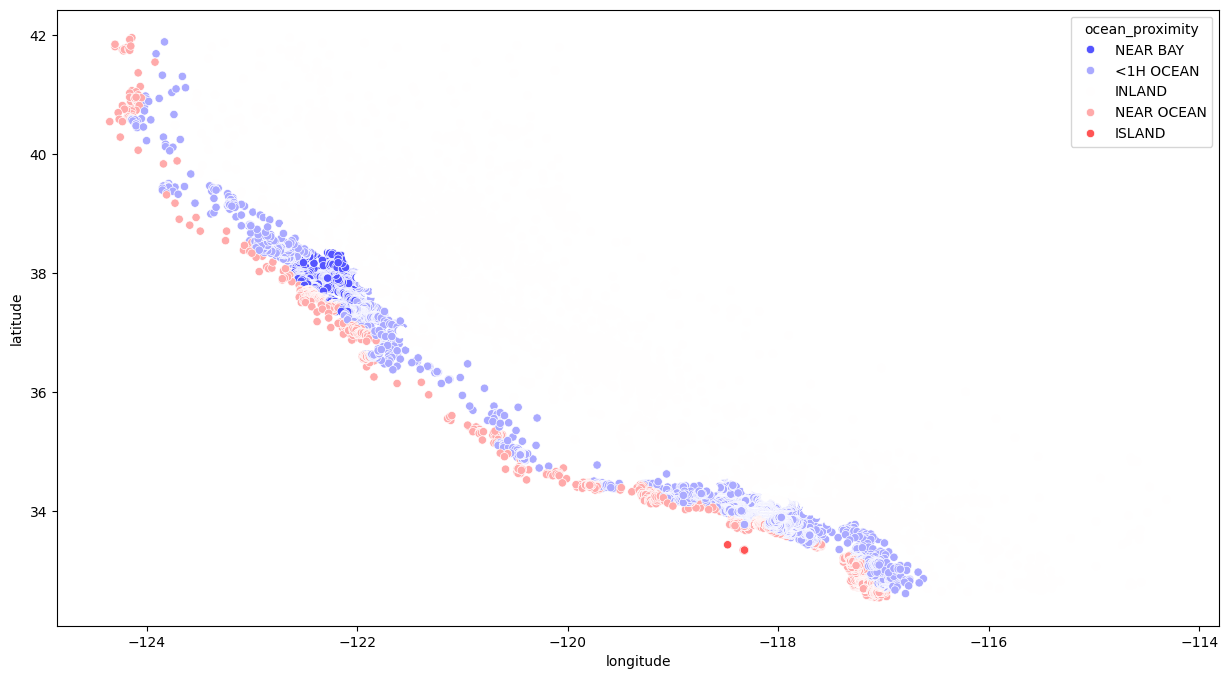

In [215]:
plt.figure(figsize=(15,8))
sns.scatterplot(x='longitude', y='latitude', data=df, hue='ocean_proximity', palette='bwr')
plt.show()

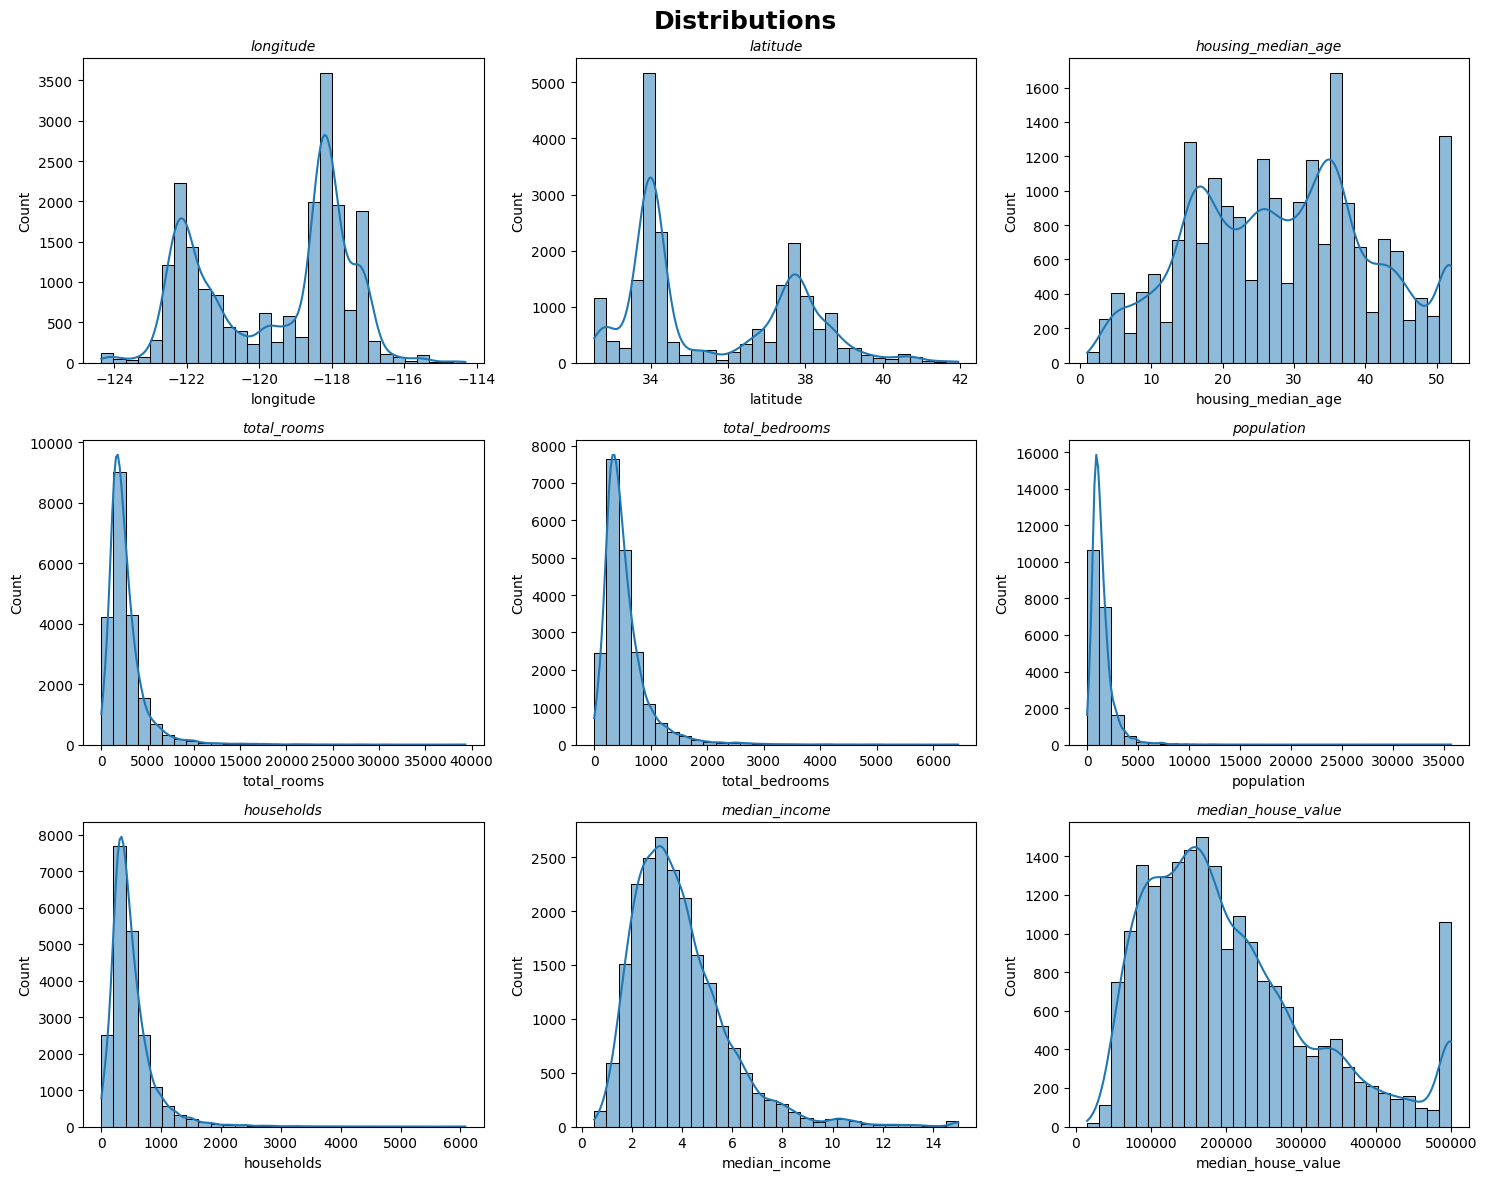

In [216]:
columns = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
        'total_bedrooms', 'population', 'households', 'median_income',
        'median_house_value']

fig , axes = plt.subplots(nrows = 3, ncols=3 , figsize=(15,12))
fig.suptitle('Distributions', fontsize = 18, fontweight = 'bold')

for i, col in enumerate (columns):
        row = i//3
        col_idx = i%3
        ax = axes[row, col_idx]
        sns.histplot(data = df, x = col, kde = True, ax = ax, bins = 30)
        ax.set_title(col, fontsize = 10, fontstyle = 'italic')

plt.tight_layout()
plt.show()

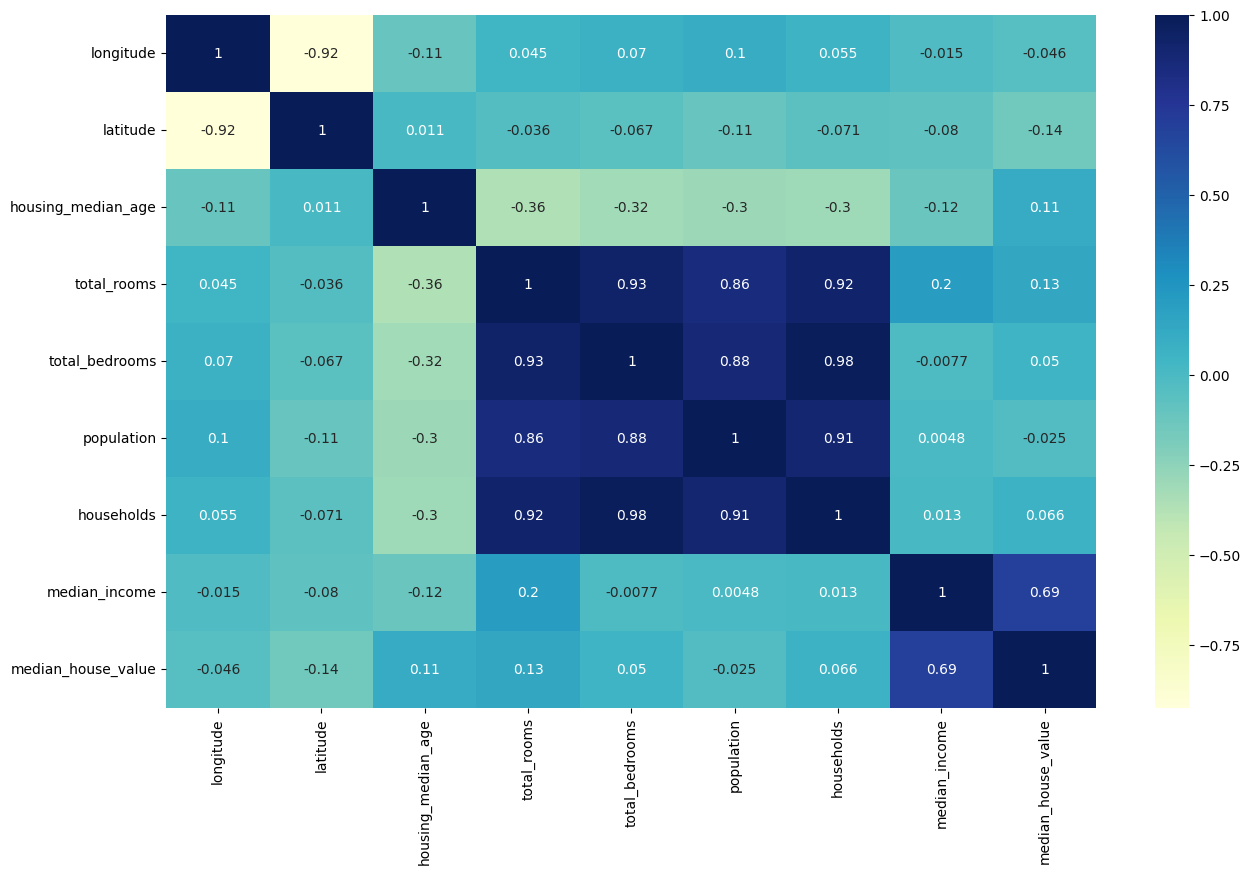

In [217]:
plt.figure(figsize=(15,9))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='YlGnBu')
plt.show()

In [218]:
def find_outliers_iqr(df, threshold = 1.5):
    outlier_summary = {}
    numeric_cols = df.select_dtypes(include=['float64','int64']).columns
    for col in numeric_cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        
        lower_bound = q1 - threshold * iqr
        upper_bound = q3 + threshold * iqr

        outlier = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_summary[col] = {
            'outliers_count':outlier.shape[0],
            'outliers_percentage':100 * (outlier.shape[0]/df.shape[0]),
            'lower_bound':lower_bound,
            'upper_bound':upper_bound
        }
    return pd.DataFrame(outlier_summary)

In [219]:
find_outliers_iqr(df, threshold= 1.5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
outliers_count,0.000,0.00,0.0,1287.000000,1271.000000,1196.000000,1220.000000,681.000000,1071.000000
outliers_percentage,0.000,0.00,0.0,6.235465,6.157946,5.794574,5.910853,3.299419,5.188953
lower_bound,-127.485,28.26,-10.5,-1102.625000,-230.500000,-620.000000,-207.500000,-0.706375,-98087.500000
upper_bound,-112.325,43.38,65.5,5698.375000,1173.500000,3132.000000,1092.500000,8.013025,482412.500000


In [220]:
columns = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
        'total_bedrooms', 'population', 'households', 'median_income',
        'median_house_value']
for col in columns:
    print(f'Skewness of {col} = {df[col].skew()}')

Skewness of longitude = -0.2978012079524362
Skewness of latitude = 0.46595300370997006
Skewness of housing_median_age = 0.060330637599136865
Skewness of total_rooms = 4.147343450632158
Skewness of total_bedrooms = 3.459546331523342
Skewness of population = 4.93585822672712
Skewness of households = 3.410437711667147
Skewness of median_income = 1.6466567021344465
Skewness of median_house_value = 0.9777632739098341


In [221]:
# Reduces skewness in right-skewed data
skewed_cols = [
    'total_rooms', 'total_bedrooms',
    'population', 'households',
    'median_income'
]

for col in skewed_cols:
    df[col] = np.log1p(df[col])

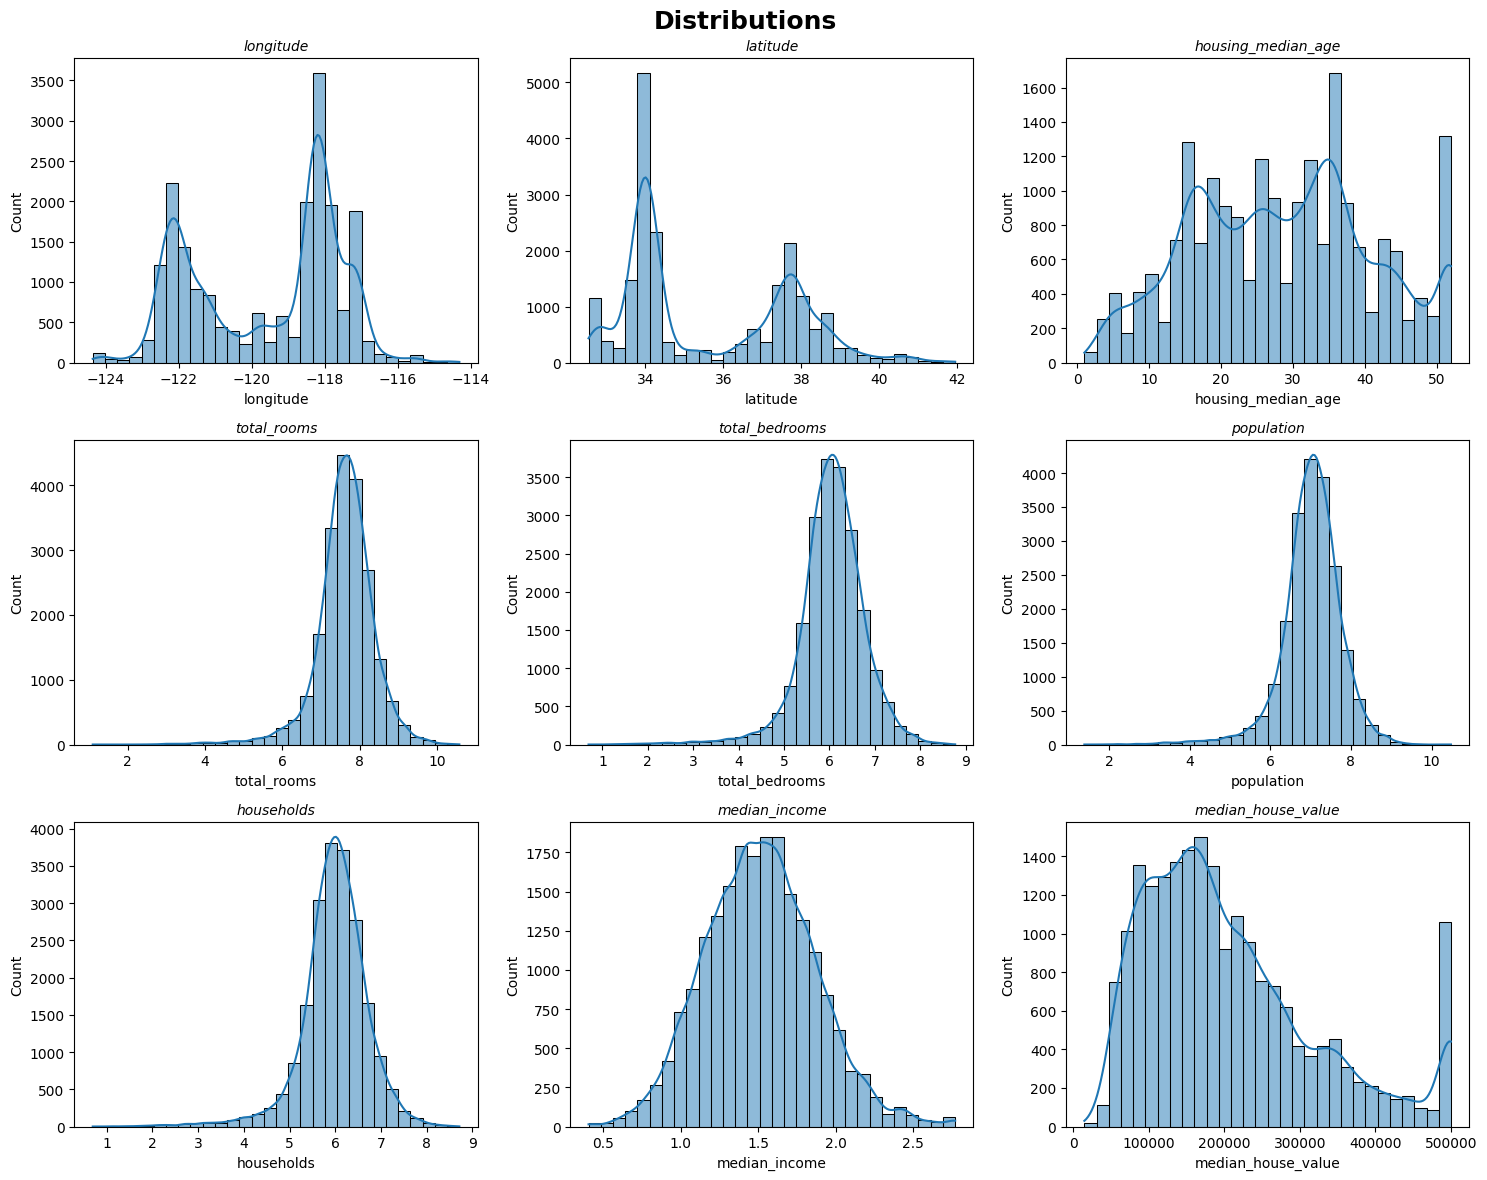

In [222]:
columns = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
        'total_bedrooms', 'population', 'households', 'median_income',
        'median_house_value']

fig , axes = plt.subplots(nrows = 3, ncols=3 , figsize=(15,12))
fig.suptitle('Distributions', fontsize = 18, fontweight = 'bold')

for i, col in enumerate (columns):
        row = i//3
        col_idx = i%3
        ax = axes[row, col_idx]
        sns.histplot(data = df, x = col, kde = True, ax = ax, bins = 30)
        ax.set_title(col, fontsize = 10, fontstyle = 'italic')

plt.tight_layout()
plt.show()

In [223]:
find_outliers_iqr(df, threshold= 1.5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
outliers_count,0.000,0.00,0.0,957.000000,819.000000,848.000000,882.000000,226.000000,1071.000000
outliers_percentage,0.000,0.00,0.0,4.636628,3.968023,4.108527,4.273256,1.094961,5.188953
lower_bound,-127.485,28.26,-10.5,6.113881,4.523494,5.493402,4.485567,0.554750,-98087.500000
upper_bound,-112.325,43.38,65.5,9.219416,7.644129,8.629658,7.559668,2.463990,482412.500000


In [224]:
def remove_outliers_from_column(df, target_col, threshold=1.5):
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        
        lower_bound = q1 - threshold*iqr
        upper_bound = q3 + threshold*iqr
        return  df[(df[col]>= lower_bound) & (df[col]<=upper_bound)]

In [225]:
print('Original data shape : ', df.shape)
df_model = remove_outliers_from_column(df,'median_house_value')
print('Only median_house_value column cleaning shape : ', df_model.shape)

Original data shape :  (20640, 10)
Only median_house_value column cleaning shape :  (19569, 10)


In [226]:
df_model['total_bedrooms'] = df_model['total_bedrooms'].fillna(df_model['total_bedrooms'].mean())

In [227]:
df_model.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,19569.0,-119.562786,2.005764,-124.350000,-121.760000,-118.510000,-117.990000,-114.310000
latitude,19569.0,35.654159,2.151007,32.540000,33.930000,34.270000,37.730000,41.950000
housing_median_age,19569.0,28.352752,12.497772,1.000000,18.000000,28.000000,37.000000,52.000000
total_rooms,19569.0,7.622885,0.748922,1.098612,7.271704,7.654917,8.046870,10.579514
total_bedrooms,19569.0,6.059746,0.719758,1.098612,5.703782,6.073045,6.470800,8.771215
population,19569.0,7.038543,0.734590,1.386294,6.682109,7.074963,7.467371,10.482430
households,19569.0,5.989492,0.724067,1.098612,5.645447,6.021023,6.408529,8.713253
median_income,19569.0,1.486294,0.329512,0.405398,1.259228,1.490925,1.717772,2.772595
median_house_value,19569.0,190852.301906,95438.555669,14999.000000,116200.000000,173200.000000,246700.000000,482200.000000


In [228]:
df_model["bedroom_ratio"] = df_model["total_bedrooms"] / df_model["total_rooms"]
df_model["household_rooms"] = df_model["total_rooms"] / df_model["households"]

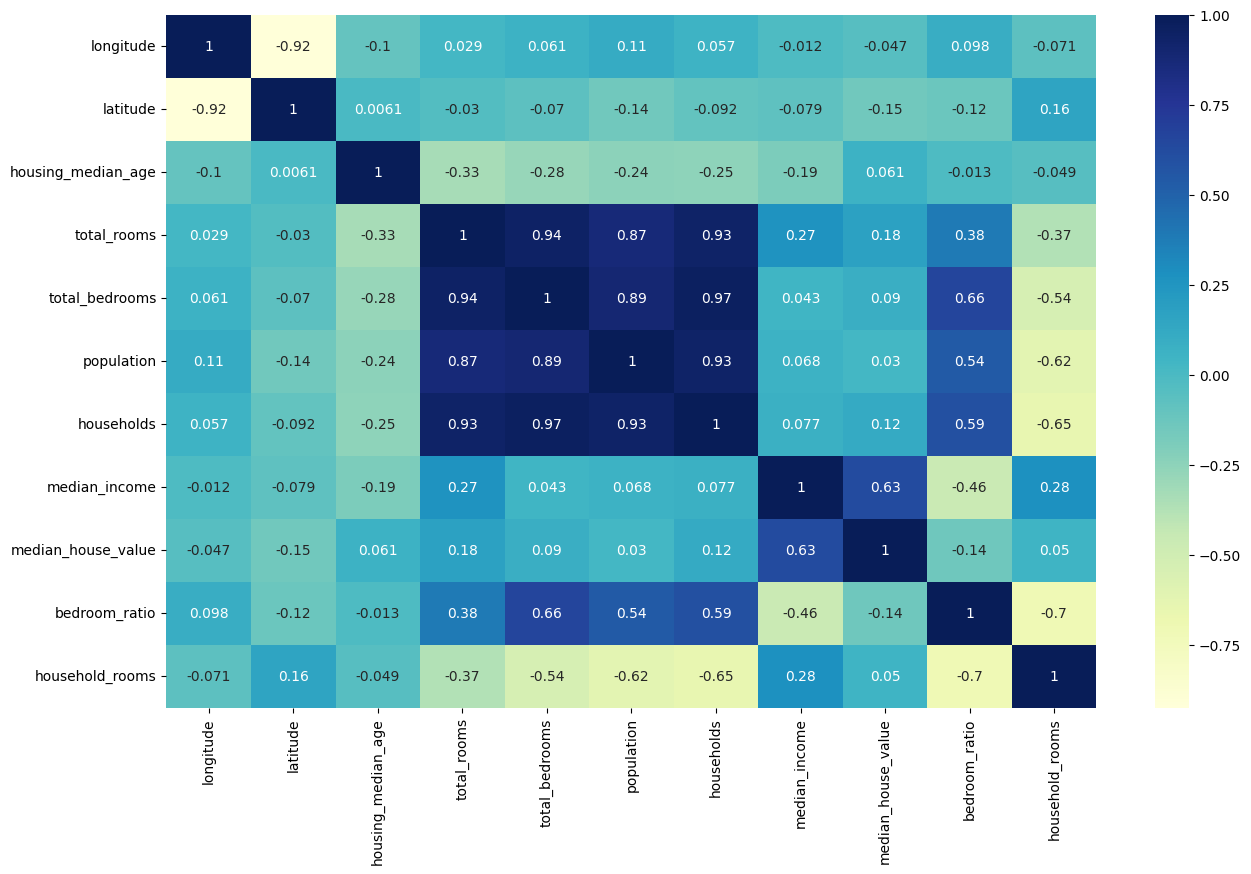

In [229]:
plt.figure(figsize=(15,9))
sns.heatmap(df_model.corr(numeric_only=True), annot=True, cmap='YlGnBu')
plt.show()

# Training Machine Learning Models

In [230]:
df_model = pd.get_dummies(df_model, columns = ['ocean_proximity'], drop_first = True,dtype=int)

In [231]:
X = df_model.drop('median_house_value', axis=1)
y = df_model['median_house_value']

In [232]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=15)

In [233]:
def evaluate_model(true,predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    rmse = np.sqrt(mean_squared_error(true,predicted))
    r2 = r2_score(true,predicted)
    return mae, rmse, r2

In [234]:
models = {
    'linear Regressin' : LinearRegression(),
    'Ridge ': Ridge(),
    'Lasso' : Lasso(),
    'Xgboost ' : XGBRegressor()
    
}

In [235]:
for name, model in models.items():

    model.fit(X_train,y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mae,train_rmse,train_r2 = evaluate_model(y_train,y_train_pred)
    test_mae,test_rmse,test_r2 = evaluate_model(y_test,y_test_pred)

    print(name)
    print('model performance for Training Set')
    print('Root mean squared error: ',train_rmse)
    print('Root mean absolute error: ',train_mae)
    print('Root r2 score: ',train_r2)
    print('-------------------------------')
    print('model performance for Test Set')
    print('Root mean squared error: ',test_rmse)
    print('Root mean absolute error: ',test_mae)
    print('Root r2 score: ',test_r2)
    print('******************************')
    print('******************************')

linear Regressin
model performance for Training Set
Root mean squared error:  59768.53402571009
Root mean absolute error:  44851.44602472099
Root r2 score:  0.6052703558748318
-------------------------------
model performance for Test Set
Root mean squared error:  59340.57037151307
Root mean absolute error:  44578.92567246745
Root r2 score:  0.6190329444882384
******************************
******************************
Ridge 
model performance for Training Set
Root mean squared error:  59772.86285866856
Root mean absolute error:  44851.549871133815
Root r2 score:  0.6052131759356083
-------------------------------
model performance for Test Set
Root mean squared error:  59351.12893611248
Root mean absolute error:  44582.92592105895
Root r2 score:  0.6188973602462067
******************************
******************************
Lasso
model performance for Training Set
Root mean squared error:  59768.79431831736
Root mean absolute error:  44849.65013414716
Root r2 score:  0.60526691776

# Hyperparameter Tuning of XGBoost

In [236]:
params = {
    "n_estimators": [100,150,200],         
    "max_depth": [3,4,5],                 
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 5],
    "gamma": [0, 0.1]
}

In [238]:
rcs = RandomizedSearchCV(estimator=XGBRegressor(), param_distributions=params, cv=5, n_jobs=-1)

In [239]:
rcs.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 1.0], 'gamma': [0, 0.1], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.

In [240]:
rcs.best_params_

{'subsample': 1.0,
 'n_estimators': 200,
 'min_child_weight': 1,
 'max_depth': 5,
 'learning_rate': 0.1,
 'gamma': 0,
 'colsample_bytree': 0.8}

In [241]:
model_rcs = XGBRegressor(n_estimators=200, subsample=0.8, min_child_weight = 1, max_depth=5, learning_rate = 0.1, gamma=0, colsample_bytree=0.8)

In [242]:
model_rcs.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [243]:
y_train_pred = model_rcs.predict(X_train)
y_test_pred = model_rcs.predict(X_test)

train_mae, train_rmse, train_r2 = evaluate_model(y_train, y_train_pred)
test_mae, test_rmse, test_r2 = evaluate_model(y_test, y_test_pred)

print("Xgboost")
print('model performance for Training Set')
print('Root mean squared error: ',train_rmse)
print('Root mean absolute error: ',train_mae)
print('Root r2 score: ',train_r2)
print('-------------------------------')
print('model performance for Test Set')
print('Root mean squared error: ',test_rmse)
print('Root mean absolute error: ',test_mae)
print('Root r2 score: ',test_r2)
print('******************************')
print('******************************')

Xgboost
model performance for Training Set
Root mean squared error:  32992.78020473047
Root mean absolute error:  23361.370483273677
Root r2 score:  0.8797202925593307
-------------------------------
model performance for Test Set
Root mean squared error:  42396.77223842183
Root mean absolute error:  29073.770368921392
Root r2 score:  0.8055313601777652
******************************
******************************


# Exporting The Model

In [244]:
pickle.dump(model_rcs, open('House_price_predictor.pkl', 'wb'))